In [2]:
from mymodels import MySqueezeNet, train, test_error, kCV
from dataUtils import *
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import Subset
from torch import nn,optim,save,load,Tensor,cat,no_grad
import matplotlib.pyplot as plt
import time
from torch.cuda import synchronize
device = 'cuda'
netName = 'squeeze'

In [2]:
best = load_json(f'HPO/{netName}net_SGD_cv.json')
print(best)
model_params = {'dropout':best['dropout']}
model = MySqueezeNet
net = model(**model_params) 
loss_fn = nn.MSELoss
optimizer = optim.SGD
increase_perc = 0
opt_params = {'lr': best['lr'], 'weight_decay':1e-4, 'momentum': best['momentum']}
epochs = 50
batch_size = best['batch_size']
epochs_loss = train(
    net,
    loss_fn(),
    optimizer(net.parameters(),**opt_params),
    epochs,
    make_train_loader(batch_size=batch_size,increase_perc=increase_perc),
    make_validation_loader(batch_size=batch_size),
    device='cuda'
)

{'dropout': 0.1, 'lr': 0.0036474588676051207, 'batch_size': 32, 'momentum': 0.8500000000000001, 'loss': 0.02702076902799308}
EPOCH 1
	train loss:	 0.052228201051602266
	val. loss:	 0.04549746689471332
EPOCH 2
	train loss:	 0.04350726357154032
	val. loss:	 0.04415584575723518
EPOCH 3
	train loss:	 0.04222761474476002
	val. loss:	 0.043274781497364696
EPOCH 4
	train loss:	 0.0413067133193559
	val. loss:	 0.04279062617570162
EPOCH 5
	train loss:	 0.04020396290844915
	val. loss:	 0.042073727754706684
EPOCH 6
	train loss:	 0.039633723436900886
	val. loss:	 0.04015763222493909
EPOCH 7
	train loss:	 0.03749496388332088
	val. loss:	 0.0398142844946547
EPOCH 8
	train loss:	 0.03478152459800834
	val. loss:	 0.03805543541569601
EPOCH 9
	train loss:	 0.03247418332992509
	val. loss:	 0.06184752454811877
EPOCH 10
	train loss:	 0.031138250364525482
	val. loss:	 0.03231274683705785
EPOCH 11
	train loss:	 0.02743488634097399
	val. loss:	 0.045687530528415336
EPOCH 12
	train loss:	 0.027324987464759608


In [4]:
dataset = make_train_val_set()
cv_loss = kCV(5,dataset,model,model_params,loss_fn,optimizer,opt_params=opt_params,epochs=epochs,batch_size=batch_size)
save(net.state_dict(), f'models/{netName}_net.pth')

FOLD 0
EPOCH 1
	train loss:	 0.05543073187867294
	val. loss:	 0.0511978493258357
EPOCH 2
	train loss:	 0.05246787541070763
	val. loss:	 0.05027844823896885
EPOCH 3
	train loss:	 0.05185253206849554
	val. loss:	 0.051002006847411394
EPOCH 4
	train loss:	 0.051323944588704984
	val. loss:	 0.04962248955853284
EPOCH 5
	train loss:	 0.050840037048091084
	val. loss:	 0.04886689256876707
EPOCH 6
	train loss:	 0.05005654996755172
	val. loss:	 0.050831909403204915
EPOCH 7
	train loss:	 0.04928153271463757
	val. loss:	 0.04754809288308024
EPOCH 8
	train loss:	 0.04828655034569757
	val. loss:	 0.04815850355662406
EPOCH 9
	train loss:	 0.04804747371117071
	val. loss:	 0.04717441884800792
EPOCH 10
	train loss:	 0.04684054622502656
	val. loss:	 0.04663128919899464
EPOCH 11
	train loss:	 0.04620003488332945
	val. loss:	 0.047576076313853265
EPOCH 12
	train loss:	 0.0454232176879839
	val. loss:	 0.04401524106040597
EPOCH 13
	train loss:	 0.04536338877503057
	val. loss:	 0.04401269346475601
EPOCH 14
	t

In [ ]:
to_json(f'results/{netName}net.json',{**epochs_loss,**{'cv':cv_loss,'test':test_error(net,make_test_set())}})

In [15]:
net = MySqueezeNet()
net.load_state_dict(load(f'models/{netName}_net.pth',weights_only=True))

<All keys matched successfully>

In [20]:
epochs_loss = load_json(f'results/{netName}net.json')
cv = epochs_loss['cv']
test = epochs_loss['test']
validation = epochs_loss['validation'][-1]
train = epochs_loss['train'][-1]
print(f'train: {train}\nvalid.: {validation}\ntest: {test}\ncv: {cv}')

train: 0.013408946583397908
valid.: 0.014374828241257505
test: 0.013086262810707691
cv: 0.02040145031642169


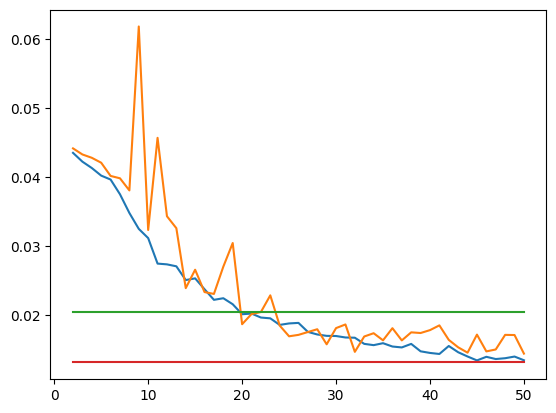

In [17]:
epochs = len(epochs_loss['validation'])
first_epoch = 2
epochsX = range(first_epoch,epochs+1)
plt.plot(epochsX, epochs_loss['train'][first_epoch-1:])
plt.plot(epochsX, epochs_loss['validation'][first_epoch-1:])
plt.plot([first_epoch,epochs], [cv]*2)
plt.plot([first_epoch,epochs], [test]*2)

In [27]:
testloader = DataLoader(
    make_test_set(), batch_size=1, shuffle=False, num_workers=2
)
net.eval()
total_time = 0
device = 'cuda'
net.to(device)
test_error(net,make_test_set(),device='cuda') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time GPU: {inf_time}')
total_time = 0
device = 'cpu'
net.to(device)
test_error(net,make_test_set(),device='cpu') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time CPU: {inf_time}')

inference time GPU: 0.0003553026854389846
inference time CPU: 0.0031651434788284192


In [8]:
param_size = 0
for param in net.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in net.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 2.929MB


In [4]:
test_load = make_test_loader()
n = len(test_load)
predicted = []
real = []
net.cpu()
net.eval()
with no_grad():
    for map,area,ate,are in test_load:
        yhat = net(map,area).squeeze(0).numpy()
        predicted += [yhat]
        real += [cat([ate,are]).numpy()]

In [9]:
Predicted = np.array([np.array(revert_data_norm(ate,are)) for ate,are in predicted])
Real = np.array([np.array(revert_data_norm(ate,are)) for ate,are in real])
pAte = Predicted[:,0]
pAre = Predicted[:,1]
rAte = Real[:,0]
rAre = Real[:,1]
R2_ate = r2_score(rAte,pAte)
R2_are = r2_score(rAre,pAre)
RMSE_ate = np.sqrt(mean_squared_error(rAte,pAte))
RMSE_are = np.sqrt(mean_squared_error(rAre,pAre))
NRMSE_ate = RMSE_ate/(pAte.max()-pAte.min())
NRMSE_are = RMSE_are/(pAre.max()-pAre.min())
print(f'ATE\n\tR2: {round(R2_ate,3)}\tRMSE: {round(RMSE_ate,3)}\tNRMSE: {round(NRMSE_ate,3)}\t')
print(f'ARE\n\tR2: {round(R2_are,3)}\tRMSE: {round(RMSE_are,3)}\tNRMSE: {round(NRMSE_are,3)}\t')

ATE
	R2: 0.505	RMSE: 1.088	NRMSE: 0.19	
ARE
	R2: 0.92	RMSE: 0.011	NRMSE: 0.056	
